# Single Image Artifact Generation Pipeline

This notebook demonstrates the complete artifact generation pipeline for a single image:
1. GSAM segmentation to identify parts and create artifact annotations
2. FLUX generation to create artifacts using patch-based guidance

Unlike the batch scripts, this notebook processes one image in-memory without saving intermediate files.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
os.chdir('/home/jhpark/image-artifacts/src')
os.environ["CUDA_VISIBLE_DEVICES"] = "2,3"


In [3]:
# Install required packages if needed
# !pip install torch torchvision transformers openai PIL numpy tqdm matplotlib
# !pip install groundingdino-py segment-anything

import sys
import uuid
import json
import time
import logging
import pickle
import random
import shutil
from datetime import datetime
from typing import List, Dict, Optional, Tuple, Any
import traceback
from collections import defaultdict

import numpy as np
import openai
import torch
from tqdm import tqdm
from PIL import Image
from transformers import Blip2Processor, Blip2ForConditionalGeneration
import matplotlib.pyplot as plt

# Add pipeline to path

from pipeline import (
    GSAMDetector, InstanceProcessor, ImageVisualizer,
)
from pipeline.data_loader import _initialize_data_loader, _get_image_list
from pipeline.prompts import get_entity_subentities, MoneyManager

/home/jhpark/anaconda3/envs/gsam/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
# Configuration - modify these as needed
CONFIG = {
    # Dataset configuration
    'dataset_type': 'coco',
    'dataset_path': '/data3/jhpark/coco/annotations',
    'image_path': '/data3/jhpark/coco/train2017',
    'super_categories': ['animal'],  # Process animal images
    
    # Processing parameters
    'max_images': 1,  # Process only one image
    'max_artifacts_per_image': 2,  # Generate 2 artifacts per image
    'artifact_types': ['fusion', 'distortion', 'removal', 'addition'],
    
    # GSAM parameters
    'min_area_ratio': 0.005,
    'max_area_ratio': 0.5,
    'box_threshold': 0.3,
    'text_threshold': 0.25,
    'device': 'cuda:0' if torch.cuda.is_available() else 'cpu',
    
    # Model paths (adjust if needed)
    'grounding_config_file': 'GroundingDINO/groundingdino/config/GroundingDINO_SwinT_OGC.py',
    'grounding_checkpoint': 'weight/groundingdino_swint_ogc.pth',
    'sam_version': 'vit_h',
    'sam_checkpoint': 'weight/sam_vit_h_4b8939.pth',
    'sam_hq_checkpoint': None,
    'use_sam_hq': False,
    'bert_base_uncased_path': None,
    
    # FLUX parameters
    'guidance': 5.0,
    'num_steps': 25,
    'inject_step': 20,
    'pe_step_addition': 25,
    'pe_step_removal': 25,
    'pe_step_distortion': 20,
    'pe_step_fusion': 20,
    'seed': 42,
    'use_rf_solver': False
}

# Set random seed for reproducibility
random.seed(CONFIG['seed'])
np.random.seed(CONFIG['seed'])
torch.manual_seed(CONFIG['seed'])
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(CONFIG['seed'])

print("Configuration loaded:")
for key, value in CONFIG.items():
    print(f"  {key}: {value}")

Configuration loaded:
  dataset_type: coco
  dataset_path: /data3/jhpark/coco/annotations
  image_path: /data3/jhpark/coco/train2017
  super_categories: ['animal']
  max_images: 1
  max_artifacts_per_image: 2
  artifact_types: ['fusion', 'distortion', 'removal', 'addition']
  min_area_ratio: 0.005
  max_area_ratio: 0.5
  box_threshold: 0.3
  text_threshold: 0.25
  device: cuda:0
  grounding_config_file: GroundingDINO/groundingdino/config/GroundingDINO_SwinT_OGC.py
  grounding_checkpoint: weight/groundingdino_swint_ogc.pth
  sam_version: vit_h
  sam_checkpoint: weight/sam_vit_h_4b8939.pth
  sam_hq_checkpoint: None
  use_sam_hq: False
  bert_base_uncased_path: None
  guidance: 5.0
  num_steps: 25
  inject_step: 20
  pe_step_addition: 25
  pe_step_removal: 25
  pe_step_distortion: 20
  pe_step_fusion: 20
  seed: 42
  use_rf_solver: False


In [5]:
# Initialize OpenAI client
if not os.getenv('OPENAI_API_KEY'):
    print("❌ Error: OPENAI_API_KEY environment variable not set.")
    print("Please set your OpenAI API key:")
    print("  export OPENAI_API_KEY='your-api-key-here'")
else:
    openai_client = openai.OpenAI()
    print("✅ OpenAI client initialized")

# Initialize MoneyManager for tracking API costs
money_manager = MoneyManager(model="gpt-4o")

✅ OpenAI client initialized


In [6]:
# Initialize models and components
print("Initializing components...")

# Initialize data loader
data_loader = _initialize_data_loader(CONFIG['dataset_type'], CONFIG)
print("✅ Data loader initialized")

# Initialize BLIP model for captioning
blip_processor = Blip2Processor.from_pretrained("Salesforce/blip2-opt-2.7b")
blip_model = Blip2ForConditionalGeneration.from_pretrained("Salesforce/blip2-opt-2.7b", device_map="cuda:0")
print("✅ BLIP model initialized")

# Initialize GSAM detector with error handling
print("Checking model file paths...")
print(f"Grounding config: {CONFIG['grounding_config_file']}")
print(f"Grounding checkpoint: {CONFIG['grounding_checkpoint']}")
print(f"SAM checkpoint: {CONFIG['sam_checkpoint']}")

# Check if files exist
import os
missing_files = []
if not os.path.exists(CONFIG['grounding_config_file']):
    missing_files.append(f"Grounding config: {CONFIG['grounding_config_file']}")
if not os.path.exists(CONFIG['grounding_checkpoint']):
    missing_files.append(f"Grounding checkpoint: {CONFIG['grounding_checkpoint']}")
if not os.path.exists(CONFIG['sam_checkpoint']):
    missing_files.append(f"SAM checkpoint: {CONFIG['sam_checkpoint']}")

if missing_files:
    print("❌ Missing model files:")
    for file in missing_files:
        print(f"  {file}")
    print("")
    print("Please download the required model files:")
    print("1. GroundingDINO: https://github.com/IDEA-Research/GroundingDINO")
    print("2. SAM: https://github.com/facebookresearch/segment-anything")
    print("")
    print("You can also update the paths in CONFIG to point to the correct locations.")
    raise FileNotFoundError("Required model files are missing")

try:
    gsam_detector = GSAMDetector(
        grounding_config_file=CONFIG['grounding_config_file'],
        grounding_checkpoint=CONFIG['grounding_checkpoint'],
        sam_version=CONFIG['sam_version'],
        sam_checkpoint=CONFIG['sam_checkpoint'],
        sam_hq_checkpoint=CONFIG['sam_hq_checkpoint'],
        use_sam_hq=CONFIG['use_sam_hq'],
        box_threshold=CONFIG['box_threshold'],
        text_threshold=CONFIG['text_threshold'],
        bert_base_uncased_path=CONFIG['bert_base_uncased_path'],
        device=CONFIG['device'],
        openai_client=openai_client
    )
    
    # Verify the model was initialized properly
    if gsam_detector.grounding_model is None:
        raise RuntimeError("GroundingDINO model failed to initialize (grounding_model is None)")
    
    print("✅ GSAM detector initialized successfully")

except Exception as e:
    print(f"❌ Error initializing GSAM detector: {e}")
    print("")
    print("This might be due to:")
    print("1. Missing or corrupted model files")
    print("2. Incorrect file paths")
    print("3. CUDA/GPU memory issues")
    print("4. Missing dependencies (GroundingDINO, segment-anything)")
    print("5. PyTorch/CUDA version compatibility issues")
    print("")
    print("Troubleshooting steps:")
    print("- Check that all model files exist at the specified paths")
    print("- Ensure you have sufficient GPU memory (at least 8GB recommended)")
    print("- Try using device='cpu' in CONFIG if GPU issues persist")
    print("- Make sure GroundingDINO and segment-anything are properly installed")
    raise

# Initialize visualizer
visualizer = ImageVisualizer()
print("✅ All components initialized successfully!")

Initializing components...
loading annotations into memory...
Done (t=0.93s)
creating index...
index created!
loading annotations into memory...
Done (t=17.66s)
creating index...


Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


index created!
✅ Data loader initialized


Loading checkpoint shards: 100%|██████████| 2/2 [00:04<00:00,  2.44s/it]


✅ BLIP model initialized
Checking model file paths...
Grounding config: GroundingDINO/groundingdino/config/GroundingDINO_SwinT_OGC.py
Grounding checkpoint: weight/groundingdino_swint_ogc.pth
SAM checkpoint: weight/sam_vit_h_4b8939.pth


final text_encoder_type: bert-base-uncased


✅ GSAM detector initialized successfully
✅ All components initialized successfully!


In [7]:
# GSAM Segmentation Processing
def process_gsam_segmentation(img_array, gsam_detector, openai_client, money_manager, config, logger):
    """Process single image with GSAM segmentation (extracted from batch_gsam_segmentation.py)"""
    
    logger.info("Getting entity subparts for all artifact types...")
    
    # Step 1: Get all entity subparts from API
    entity_subentity_response = get_entity_subentities(openai_client, img_array, money_manager)
    if not entity_subentity_response or 'error' in entity_subentity_response:
        raise RuntimeError("Failed to get entity subparts")
    if not entity_subentity_response.peripheral and not entity_subentity_response.intermediate:
        raise ValueError("Both peripheral and intermediate entity subentity lists are empty")
        
    # Transform the response into a nested dictionary structure
    peripheral_entities = set()
    peripheral_subentities = set()
    peripheral_entity_subentity_mapping = defaultdict(list)
    intermediate_entities = set()
    intermediate_subentities = set()
    intermediate_entity_subentity_mapping = defaultdict(list)
    all_entity_subentity_mapping = defaultdict(list)

    for vocab in entity_subentity_response.peripheral:
        peripheral_entities.add(vocab.entity)
        peripheral_subentities.update(vocab.subentities)
        for subentity in vocab.subentities:
            peripheral_entity_subentity_mapping[subentity].append(vocab.entity)
            all_entity_subentity_mapping[subentity].append(vocab.entity)
    for vocab in entity_subentity_response.intermediate:
        intermediate_entities.add(vocab.entity)
        intermediate_subentities.update(vocab.subentities)
        for subentity in vocab.subentities:
            intermediate_entity_subentity_mapping[subentity].append(vocab.entity)
            all_entity_subentity_mapping[subentity].append(vocab.entity)
    all_entities = peripheral_entities | intermediate_entities
    all_subentities = peripheral_subentities | intermediate_subentities

    logger.info(f"Found entities: {all_entities}")
    logger.info(f"Found subentities: {all_subentities}")
    
    # Step 2: Single detection call with combined vocabulary
    logger.info("Detecting parts using Grounded SAM...")
    predictions, entity_predictions, visualized_output = gsam_detector.detect_parts(
        img_array, list(all_entities), list(all_subentities), all_entity_subentity_mapping,
        min_area_ratio=config['min_area_ratio'], max_area_ratio=config['max_area_ratio']
    )
    
    # Step 3: Sample target parts with entity-aware logic
    logger.info("Sampling target parts across all entities...")

    artifacts = defaultdict(list)
    for entity_prediction in entity_predictions:
        entity = entity_prediction['entity']
        try:
            annotation = create_fusion_artifact_annotations(
                entity_prediction,
                entity_predictions,
                predictions,
                entity,
                img_array,
                None,  # No image output dir
                None   # No img filename
            )
            artifacts['fusion'].append(annotation)
        except Exception as e:
            logger.error(f"Cannot create fusion artifact for {entity}: {str(e)}")
            continue

    if len(artifacts) == 0:
        logger.info("No artifacts were created successfully. Generating image with no artifacts")
        return []
    
    # Sample final artifacts with completely non-overlapping patches
    max_artifacts = config['max_artifacts_per_image']
    
    selected_artifacts = sample_multiple_target_artifacts(
        artifacts,
        max_artifacts=max_artifacts,
        artifact_distribution={'fusion': 0, 'distortion': 0, 'removal': 0, 'addition': 0}  # Start fresh
    )

    if not selected_artifacts:
        logger.error("No valid target parts found across all artifact types after sampling")
        raise RuntimeError("No valid target parts found after sampling")
        
    logger.info(f"✅ Successfully selected {len(selected_artifacts)} non-overlapping artifacts")
    
    return selected_artifacts, visualized_output

def create_fusion_artifact_annotations(
    entity_prediction: Dict,
    entity_predictions: Any,
    predictions: Any,
    entity: str,
    img_array: np.ndarray,
    image_output_dir: str = None,
    img_filename: str = None
) -> Dict[str, Any]:
    """Create fusion artifact annotations (simplified version without file saving)"""
    target_patches, reference_patches, fused_entity, coord_dict = InstanceProcessor.create_fusion_artifact_patches(
        entity_prediction,
        entity_predictions,
        predictions,
        img_array,
        patch_size=16,
        output_dir=None,  # No output dir
        img_filename=None  # No filename
    )

    target_bbox = InstanceProcessor.patch_coords_to_bbox(target_patches, patch_size=16)
    reference_bbox = InstanceProcessor.patch_coords_to_bbox(reference_patches, patch_size=16)

    target_mask = InstanceProcessor.patches_to_masks(target_patches, img_array.shape, patch_size=16)
    reference_mask = InstanceProcessor.patches_to_masks(reference_patches, img_array.shape, patch_size=16)

    target_patch_indices, reference_patch_indices = InstanceProcessor.map_coords_to_patch_indices(
        artifact_type='fusion',
        target_patches=target_patches,
        reference_patches=reference_patches,
        img_shape=img_array.shape,
        patch_size=16
    )

    result_dict = {
        'artifact_type': 'fusion',
        'entity': entity,
        'fused_entity': fused_entity,
        'target_bbox': target_bbox,
        'reference_bbox': reference_bbox,
        'target_patch_indices': target_patch_indices,
        'reference_patch_indices': reference_patch_indices,
        'target_mask': target_mask,
        'reference_mask': reference_mask,
        'distortion_kernel': None,
        'coord_dict': coord_dict
    }

    return result_dict

def sample_multiple_target_artifacts(
    annotations: Dict[str, List[Dict[str, Any]]], 
    max_artifacts: int,
    artifact_distribution: Dict[str, int] = None
) -> List[Dict[str, Any]]:
    """Sample multiple target artifacts with non-overlapping patches"""
    
    # Flatten annotations from dict to list
    all_annotations = []
    for artifact_type, artifact_list in annotations.items():
        all_annotations.extend(artifact_list)
    
    if not all_annotations:
        return []
    
    # For simplicity in single image case, just take the first few
    selected_artifacts = []
    
    def has_any_patch_overlap(new_artifact: Dict, existing_artifacts: List[Dict]) -> bool:
        """Check if new artifact has any patch overlap with existing ones."""
        new_target_patches = set(new_artifact['target_patch_indices'])
        new_reference_patches = set(new_artifact['reference_patch_indices'])
        
        for existing_artifact in existing_artifacts:
            existing_target_patches = set(existing_artifact['target_patch_indices'])
            existing_reference_patches = set(existing_artifact['reference_patch_indices'])
            
            # Calculate union of all patches for each artifact
            new_all_patches = new_target_patches | new_reference_patches
            existing_all_patches = existing_target_patches | existing_reference_patches
            
            # Check for any overlap between the unions
            if new_all_patches & existing_all_patches:
                return True
                
        return False
    
    # Select artifacts one by one, avoiding any spatial conflicts
    for annotation in all_annotations:
        if len(selected_artifacts) >= max_artifacts:
            break
            
        # Check for any patch overlap with already selected artifacts
        if not has_any_patch_overlap(annotation, selected_artifacts):
            selected_artifacts.append(annotation)
    
    return selected_artifacts

print("GSAM segmentation functions loaded")

GSAM segmentation functions loaded


In [8]:
# Get one image to process
print("Loading image list...")
image_list = _get_image_list(
    CONFIG['dataset_type'], 
    data_loader, 
    CONFIG['super_categories'], 
    CONFIG['max_images'],
    max_instances_per_image=5,
    logger=logging.getLogger()
)

print(f"Found {len(image_list)} images")
if len(image_list) == 0:
    print("❌ No images found. Please check your dataset path and categories.")
else:
    print("✅ Image list loaded")
    
# Select first image
image_iter = iter(image_list)

Loading image list...
Counting instances per image...
number of images 15474
Found 15474 images
✅ Image list loaded


Running GSAM segmentation...
Before NMS: 3 boxes


Cannot create fusion artifact for tire: No valid overlapping entity found for fusion artifact


Found 2 entity detections and 1 subentity detections
Discarded entity 'bird' (class 1) - area ratio 0.0081 outside range [0.005, 0.5]
Kept entity 'tire' (class 0) with area ratio 0.2616
Discarded subentity 'tail' - no valid entity mapping (best containment ratio: 0.000)
After entity mapping and area ratio filtering: 0 detections remain
Returning 0 mapped subentity detections and 1 entity detections
❌ Error in GSAM segmentation: not enough values to unpack (expected 2, got 0)
Running GSAM segmentation...
Before NMS: 5 boxes


Cannot create fusion artifact for zebra: No valid overlapping entity found for fusion artifact


Found 1 entity detections and 4 subentity detections
Kept entity 'zebra' (class 0) with area ratio 0.0485
Mapped subentity 'tail' to entity 'zebra' with containment ratio 1.000
Discarded subentity 'ear' - no valid entity mapping (best containment ratio: 0.000)
Discarded subentity 'leg' - no valid entity mapping (best containment ratio: 0.000)
Mapped subentity 'face' to entity 'zebra' with containment ratio 1.000
After entity mapping and area ratio filtering: 2 detections remain
Returning 2 mapped subentity detections and 1 entity detections
❌ Error in GSAM segmentation: not enough values to unpack (expected 2, got 0)
Running GSAM segmentation...
Before NMS: 6 boxes


...

Found 1 entity detections and 4 subentity detections
Kept entity 'bird' (class 0) with area ratio 0.0480
Discarded subentity 'beak' - area ratio 0.0014 outside range [0.005, 0.5]
Mapped subentity 'leg' to entity 'bird' with containment ratio 1.000
Mapped subentity 'head' to entity 'bird' with containment ratio 1.000
Mapped subentity 'wing' to entity 'bird' with containment ratio 1.000
After entity mapping and area ratio filtering: 3 detections remain
Returning 3 mapped subentity detections and 1 entity detections
❌ Error in GSAM segmentation: not enough values to unpack (expected 2, got 0)
Running GSAM segmentation...
Before NMS: 6 boxes


Cannot create fusion artifact for bird: No valid overlapping entity found for fusion artifact


Found 1 entity detections and 5 subentity detections
Kept entity 'bird' (class 0) with area ratio 0.1496
Mapped subentity 'beak' to entity 'bird' with containment ratio 1.000
Discarded subentity 'eye' - area ratio 0.0007 outside range [0.005, 0.5]
Mapped subentity 'head' to entity 'bird' with containment ratio 1.000
Mapped subentity 'tail' to entity 'bird' with containment ratio 1.000
Mapped subentity 'wing' to entity 'bird' with containment ratio 1.000
After entity mapping and area ratio filtering: 4 detections remain
Returning 4 mapped subentity detections and 1 entity detections
❌ Error in GSAM segmentation: not enough values to unpack (expected 2, got 0)
Running GSAM segmentation...
❌ Error in GSAM segmentation: Both peripheral and intermediate entity subentity lists are empty
Running GSAM segmentation...
Before NMS: 3 boxes
Found 1 entity detections and 2 subentity detections
Discarded entity 'bird' (class 0) - area ratio 0.0053 outside range [0.005, 0.5]
Discarded subentity 'beak

Cannot create fusion artifact for building: No valid overlapping entity found for fusion artifact


Found 4 entity detections and 1 subentity detections
Kept entity 'building' (class 0) with area ratio 0.3943
Discarded entity 'bird' (class 2) - area ratio 0.0005 outside range [0.005, 0.5]
Discarded entity 'bird' (class 2) - area ratio 0.0008 outside range [0.005, 0.5]
Discarded entity 'bird' (class 2) - area ratio 0.0005 outside range [0.005, 0.5]
Mapped subentity 'fire escape' to entity 'building' with containment ratio 1.000
After entity mapping and area ratio filtering: 1 detections remain
Returning 1 mapped subentity detections and 1 entity detections
❌ Error in GSAM segmentation: not enough values to unpack (expected 2, got 0)
Running GSAM segmentation...
Before NMS: 4 boxes
Found 2 entity detections and 2 subentity detections
Kept entity 'bird' (class 0) with area ratio 0.1641
Kept entity 'bird' (class 0) with area ratio 0.1503
Mapped subentity 'beak' to entity 'bird' with containment ratio 1.000
Discarded subentity 'eye' - area ratio 0.0006 outside range [0.005, 0.5]
After ent

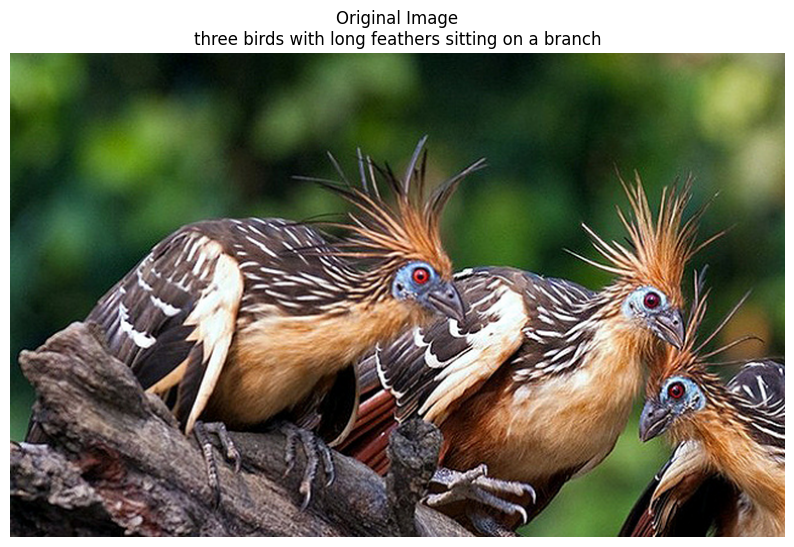

In [17]:

for img_info in image_list:
    # Load and display the selected image
    img_info = next(image_iter)
    if hasattr(data_loader, 'load_image_by_info'):
        img_array = data_loader.load_image_by_info(img_info)
    else:
        img_array = data_loader.load_image_by_path(img_info['file_path'])

    # Run GSAM segmentation
    logger = logging.getLogger()
    logger.setLevel(logging.INFO)

    print("Running GSAM segmentation...")
    start_time = time.time()
    try:
        artifacts, visualized_output = process_gsam_segmentation(
            img_array, gsam_detector, openai_client, money_manager, CONFIG, logger
        )
    except Exception as e:
        print(f"❌ Error in GSAM segmentation: {str(e)}")
        continue
    if artifacts:
        has_fusion_artifact = any(a.get('artifact_type') == 'fusion' for a in artifacts)
        if has_fusion_artifact:
            break

    processing_time = time.time() - start_time
    print(f"✅ GSAM segmentation completed in {processing_time:.2f} seconds")
    print(f"Generated {len(artifacts)} artifacts")

# Display artifact summary
artifact_types = [a['artifact_type'] for a in artifacts]
print(f"Artifact types: {artifact_types}")

for i, artifact in enumerate(artifacts):
    print(f"  Artifact {i+1}: {artifact['artifact_type']} - {artifact['entity']}")
    if artifact['artifact_type'] == 'fusion':
        print(f"    Fused entity: {artifact['fused_entity']}")

# Generate caption using BLIP
print("Generating caption...")
inputs = blip_processor(img_array, return_tensors="pt").to(CONFIG['device'])
out = blip_model.generate(**inputs)
caption = blip_processor.decode(out[0], skip_special_tokens=True).strip()
print(f"Caption: {caption}")

# Display the image
print(f"Selected image: {img_info['file_name']} (ID: {img_info['id']})")
plt.figure(figsize=(10, 8))
plt.imshow(img_array)
plt.title(f"Original Image\n{caption}")
plt.axis('off')
plt.show()


Displaying GSAM segmentation visualization...


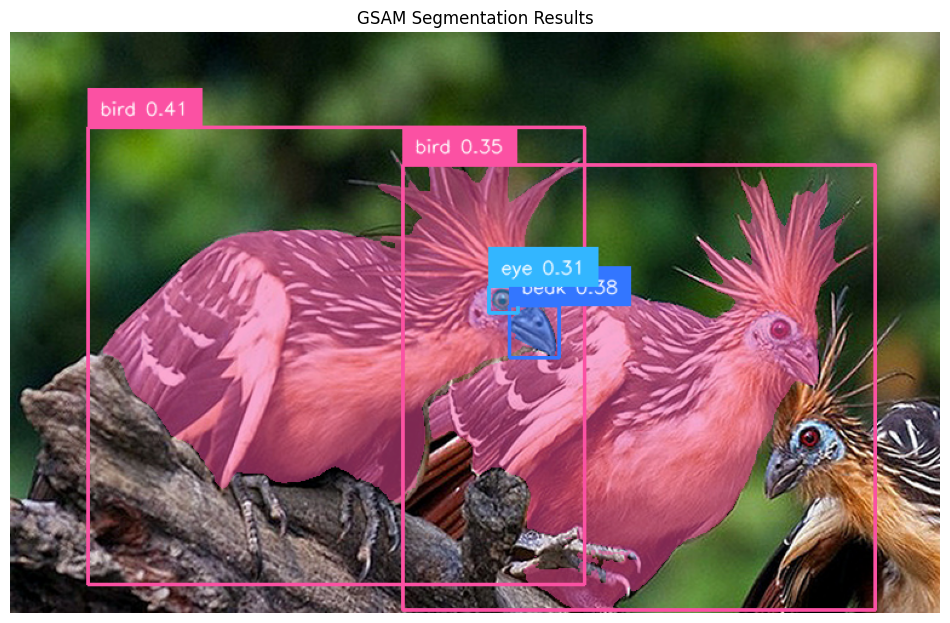

In [18]:
# Display GSAM visualization if available
if 'visualized_output' in locals() and visualized_output is not None:
    print("Displaying GSAM segmentation visualization...")
    plt.figure(figsize=(12, 8))
    plt.imshow(visualized_output)
    plt.title("GSAM Segmentation Results")
    plt.axis('off')
    plt.show()
else:
    print("No GSAM visualization available")

In [19]:
# FLUX Generation
def run_flux_generation(img_array, caption, artifacts, flux_generator, visualizer):
    """Run FLUX artifact generation (extracted from batch_flux_generation.py)"""
    
    print(f"Generating FLUX artifacts...")
            
    # Check if there are fusion artifacts
    has_fusion = any(a.get('artifact_type') == 'fusion' for a in artifacts)
    if not has_fusion:
        print("No 'fusion' artifact found, skipping FLUX generation")
        return None
    
    # Run artifact injection with patch annotations
    generated_image = flux_generator.inject_artifacts(
        source_prompt=caption,
        target_prompt=caption,
        artifact_data=artifacts,
        source_img=Image.fromarray(img_array)
    )
    
    return generated_image

print("FLUX generation function loaded")

FLUX generation function loaded


In [ ]:
# Run FLUX generation
print("Running FLUX artifact generation...")
start_time = time.time()

try:
    generated_image = run_flux_generation(
        img_array, caption, artifacts, flux_generator, visualizer
    )
    
    if generated_image is not None:
        processing_time = time.time() - start_time
        print(f"✅ FLUX generation completed in {processing_time:.2f} seconds")
    else:
        print("❌ FLUX generation failed or was skipped")

except Exception as e:
    print(f"❌ Error in FLUX generation: {str(e)}")
    traceback.print_exc()

Running FLUX artifact generation...
❌ Error in FLUX generation: name 'artifacts' is not defined


Traceback (most recent call last):
  File "/tmp/ipykernel_1832038/3893684572.py", line 7, in <module>
    img_array, caption, artifacts, flux_generator, visualizer
NameError: name 'artifacts' is not defined


In [ ]:
# Display results
if 'generated_image' in locals() and generated_image is not None:
    print("Displaying results...")
    
    # Create side-by-side comparison
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))
    
    # Original image
    ax1.imshow(img_array)
    ax1.set_title(f"Original Image\n{caption}", fontsize=12)
    ax1.axis('off')
    
    # Generated image with artifacts
    ax2.imshow(generated_image)
    ax2.set_title(f"Generated with Artifacts\n{caption}", fontsize=12)
    ax2.axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # Display artifact details
    print("\nArtifact Details:")
    for i, artifact in enumerate(artifacts):
        print(f"  Artifact {i+1}: {artifact['artifact_type']} - {artifact['entity']}")
        if artifact['artifact_type'] == 'fusion':
            print(f"    Fused entity: {artifact['fused_entity']}")
else:
    print("No generated image to display")

No generated image to display


In [ ]:
# Cleanup and summary
print("\nCleaning up...")

# Cleanup models
try:
    gsam_detector.cleanup()
    flux_generator.unload_models()
    print("✅ Models cleaned up")
except:
    pass

# Print summary
print("\n" + "="*60)
print("PIPELINE SUMMARY")
print("="*60)
print(f"Image processed: {img_info['file_name']} (ID: {img_info['id']})")
print(f"Caption: {caption}")
print(f"Artifacts generated: {len(artifacts) if 'artifacts' in locals() else 0}")

if 'artifacts' in locals():
    artifact_types = [a['artifact_type'] for a in artifacts]
    print(f"Artifact types: {artifact_types}")

print(f"Total API cost: ${money_manager.total_cost:.4f}")
print("="*60)


Cleaning up...

PIPELINE SUMMARY
Image processed: 000000425988.jpg (ID: 425988)
Caption: two geese swimming in a lake
Artifacts generated: 0
Total API cost: $0.0056
